# 01 — A PyTorch TCOCNN: architecture and components

A Temperature-Cycled Operation Convolutional Neural Network receives a complete temperature-cycle
signal instead of isolated steady-state points. Convolutions learn temporal patterns such as slopes,
peaks, and relaxation. This notebook uses fictional data with exactly **one customer sub-sensor** so
every component can be inspected without loading the full dataset.

## Typical components

- `Conv2d` with kernel height 1 moves a temporal filter along the single sensor row.
- `BatchNorm2d` stabilizes intermediate activation scales.
- `ReLU` introduces nonlinearity.
- `MaxPool2d` reduces time resolution and increases receptive field.
- `AdaptiveAvgPool2d` creates a fixed representation.
- `Dropout` regularizes the dense representation.
- `Linear` maps learned features to one concentration.

The PyTorch input layout is `(batch, input_channels, sub-sensors, time)`. Here the sub-sensor
dimension always has length one.

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

class TeachingTCOCNN(nn.Module):
    def __init__(self,n_sensors=1,n_outputs=1,filters=32,kernel=9,dropout=.15):
        super().__init__()
        # A (1 × kernel) filter moves only through time, not across sensor rows.
        self.features=nn.Sequential(
            nn.Conv2d(1,filters,kernel_size=(1,kernel),padding=(0,kernel//2)),
            nn.BatchNorm2d(filters), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1,4)),
            nn.Conv2d(filters,2*filters,kernel_size=(1,5),padding=(0,2)),
            nn.BatchNorm2d(2*filters), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.head=nn.Sequential(nn.Flatten(),nn.Dropout(dropout),nn.Linear(2*filters,n_outputs))
    def forward(self,x):
        features=self.features(x)
        return self.head(features)

model=TeachingTCOCNN(); print(model)

TeachingTCOCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(1, 9), stride=(1, 1), padding=(0, 4))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.15, inplace=False)
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Follow the tensor shapes

Hooks show what each layer does. Convolution changes feature-map count, pooling shortens time,
global pooling removes the remaining sensor/time dimensions, and the dense head returns one value
per sample. The accompanying heatmaps make both the input matrix and learned activations visible.

In [2]:
# Eight fictional samples, one input channel, one customer sub-sensor, 144 time points.
X_demo=torch.randn(8,1,1,144)
handles=[]
for name,layer in model.named_modules():
    if isinstance(layer,(nn.Conv2d,nn.MaxPool2d,nn.AdaptiveAvgPool2d,nn.Linear)):
        handles.append(layer.register_forward_hook(lambda module,inputs,output,n=name: print(f'{n:<12}: {tuple(inputs[0].shape)} -> {tuple(output.shape)}')))
prediction=model(X_demo)
for handle in handles: handle.remove()
print('Final prediction:',prediction.shape)

features.0  : (8, 1, 1, 144) -> (8, 32, 1, 144)
features.3  : (8, 32, 1, 144) -> (8, 32, 1, 36)
features.4  : (8, 32, 1, 36) -> (8, 64, 1, 36)
features.7  : (8, 64, 1, 36) -> (8, 64, 1, 1)
head.2      : (8, 64) -> (8, 1)
Final prediction: torch.Size([8, 1])


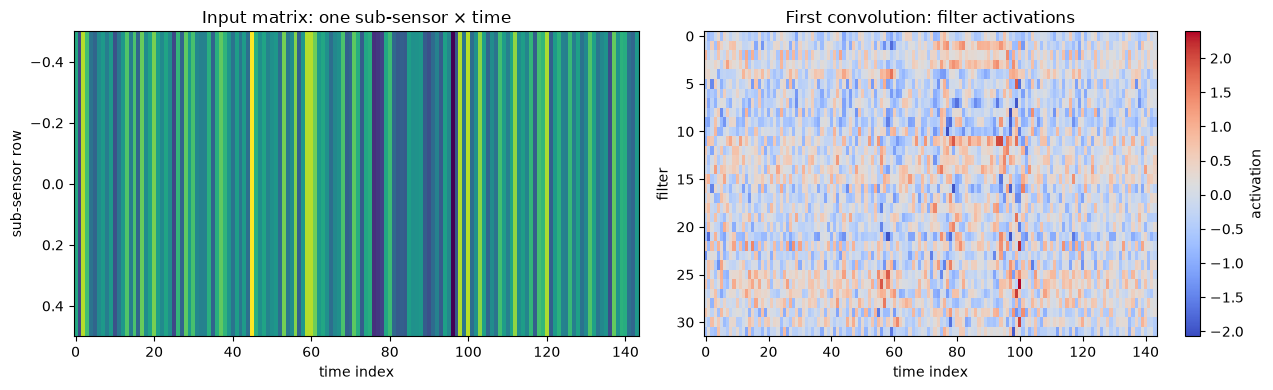

In [3]:
import matplotlib.pyplot as plt

with torch.no_grad():
    first_activation = model.features[0](X_demo[:1])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(X_demo[0, 0].numpy(), aspect="auto", cmap="viridis")
axes[0].set(
    title="Input matrix: one sub-sensor × time",
    xlabel="time index",
    ylabel="sub-sensor row",
)
image = axes[1].imshow(
    first_activation[0, :, 0, :].numpy(),
    aspect="auto",
    cmap="coolwarm",
)
axes[1].set(
    title="First convolution: filter activations",
    xlabel="time index",
    ylabel="filter",
)
fig.colorbar(image, ax=axes[1], label="activation")
fig.tight_layout()

## Relation to this repository

`Networks/TCOCNN.py` provides the original strided architecture; `TCOCNNs.py` uses pooling;
`TCOCNNv2.py` uses paired convolutions and global average pooling; `TCOCNNv3.py` adds deeper optional
residual blocks. The wrapper accepts `(samples, sub-sensors, time, channels)`. Day 3 always supplies
exactly one sub-sensor.

In [4]:
from pathlib import Path
import sys
HERE=Path.cwd()
if not (HERE/'day3_utils.py').exists(): HERE=HERE/'Evaluation Seminar'/'Day_03'
ROOT=HERE.parents[1]
sys.path.insert(0,str(HERE)); sys.path.insert(0,str(ROOT/'Networks'))

from TCOCNN import TCOCNNClass
params={'n_filter':32,'section_depth':3,'kernel':9,'stride':4,'num_neurons':256,'drop_out':.1,'initial_learning_rate':1e-3}
wrapper=TCOCNNClass((1,1440,1),1,regression=True,device='cpu')
wrapper.build_net(params); wrapper.compile_model(params['initial_learning_rate'])
print(wrapper.model)

TCOCNNModule(
  (features): Sequential(
    (0): SamePadConv2d(
      (conv): Conv2d(1, 32, kernel_size=(1, 9), stride=(1, 4))
    )
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): SamePadConv2d(
      (conv): Conv2d(32, 32, kernel_size=(1, 9), stride=(1, 1))
    )
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): SamePadConv2d(
      (conv): Conv2d(32, 64, kernel_size=(1, 2), stride=(1, 2))
    )
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): SamePadConv2d(
      (conv): Conv2d(64, 64, kernel_size=(1, 2), stride=(1, 1))
    )
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): SamePadConv2d(
      (conv): Conv2d(64, 96, kernel_size=(1, 2), stride=(1, 2))
    )
    (13): BatchNorm2d(96